In [1]:
import pandas as pd
import numpy as np

df = pd.read_pickle('data/df.pkl')
df = df.drop('geometry', axis = 1)
# df = df.drop('date', axis = 1)
columns = df.columns

df = df.sample(frac = 1)

# df_val = df[df['year'] == 2025].copy()
# df = df.drop(df_val.index)
# # Define features and target
columns = [(col) for col in df.columns]
non_features = [
    (col) for col in df.columns if 'ndvi' in str(col) or 'late' in str(col)
] + [
    'year', 'month','plot_id', 'geometry', 'key_0', 'area_m2'
] + [
    i for i in range(0, 367, 1)
]
features = [(col) for col in df.columns if col not in non_features]
target = ((df['ndvi_integral']))
X = df[features]

# --- Plot-wise train / val / test split ---
plots = df['plot_id'].unique()
np.random.shuffle(plots)

n_train = int(len(plots)*0.7)
n_val   = int(len(plots)*0.15)

train_plots = plots[:n_train]
val_plots   = plots[n_train:n_train+n_val]
test_plots  = plots[n_train+n_val:]

train_mask = df['plot_id'].isin(train_plots)
val_mask   = df['plot_id'].isin(val_plots)
test_mask  = df['plot_id'].isin(test_plots)

X_train, y_train = X[train_mask], target[train_mask]
X_val, y_val     = X[val_mask], target[val_mask]
X_test, y_test   = X[test_mask], target[test_mask]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (3252, 81), Val: (696, 81), Test: (744, 81)


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Initialize
rf = RandomForestRegressor(
    n_estimators=500,      # number of trees
    max_depth=10,          # limit tree depth to reduce overfitting
    min_samples_leaf=5,    # minimum samples per leaf
    max_features='sqrt',   # use sqrt of features at each split
    random_state=42,
    n_jobs=-1
)

# Fit
rf.fit(X_train, y_train)

# Predict
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# Evaluate
print("Random Forest R² (val):", r2_score(y_val, y_val_pred))
print("Random Forest RMSE (val):", mean_squared_error(y_val, y_val_pred, squared=False))
print("Random Forest R² (test):", r2_score(y_test, y_test_pred))
print("Random Forest RMSE (test):", mean_squared_error(y_test, y_test_pred, squared=False))


Random Forest R² (val): 0.6694767922156706
Random Forest RMSE (val): 7.967953247477826
Random Forest R² (test): 0.4967833917564831
Random Forest RMSE (test): 9.635958163369937


In [3]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)

# Fit with early stopping on validation
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=50,
    verbose=False
)

# Predict
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

# Evaluate
print("XGBoost R² (val):", r2_score(y_val, y_val_pred))
print("XGBoost RMSE (val):", mean_squared_error(y_val, y_val_pred, squared=False))
print("XGBoost R² (test):", r2_score(y_test, y_test_pred))
print("XGBoost RMSE (test):", mean_squared_error(y_test, y_test_pred, squared=False))


/home/simonhans/anaconda3/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,


XGBoost R² (val): 0.611008444071898
XGBoost RMSE (val): 8.644022419867651
XGBoost R² (test): 0.4535128124485187
XGBoost RMSE (test): 10.04170398404144


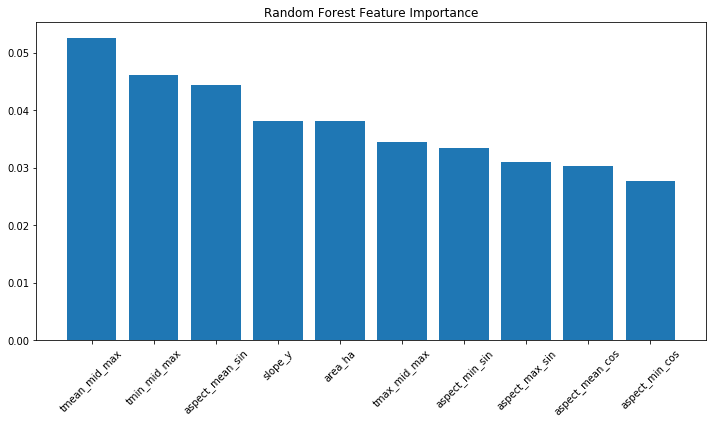

In [4]:
import matplotlib.pyplot as plt

# Random Forest feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Random Forest Feature Importance")
plt.bar(range(10), importances[indices[:10]], align='center')
plt.xticks(range(10), [features[i] for i in indices[:10]], rotation=45)
plt.tight_layout()
plt.show()


In [5]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [6]:
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.09,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    random_state=42,
    eval_metric='rmse'
)

In [7]:
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    early_stopping_rounds=50,
    verbose=False
)

/home/simonhans/anaconda3/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.7,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.09, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=5,
             missing=nan, monotone_constraints='()', n_estimators=2000,
             n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

In [8]:
# y_test = np.exp(y_test)
# y = np.exp(y)
y_pred = (xgb_model.predict(X_test))
r2 = r2_score(y_test, y_pred)
print('Test R²:', r2)

Test R²: 0.49466641152495083


In [9]:
importances = xgb_model.feature_importances_
feat_imp = dict(zip(X.columns, importances))
print('Top features:', sorted(feat_imp.items(), key=lambda x: x[1], reverse=True)[:10])

Top features: [('tmean_mid_max', 0.3587003), ('tmin_mid_max', 0.21490814), ('tmax_mid_min', 0.046171147), ('aspect_min_sin', 0.03524023), ('aspect_mean_sin', 0.028454402), ('tmax_early_max', 0.021334983), ('area_ha', 0.018666264), ('slope_y', 0.01772637), ('tmin_early_max', 0.016840108), ('vpdmin_mid_mean', 0.015894491)]


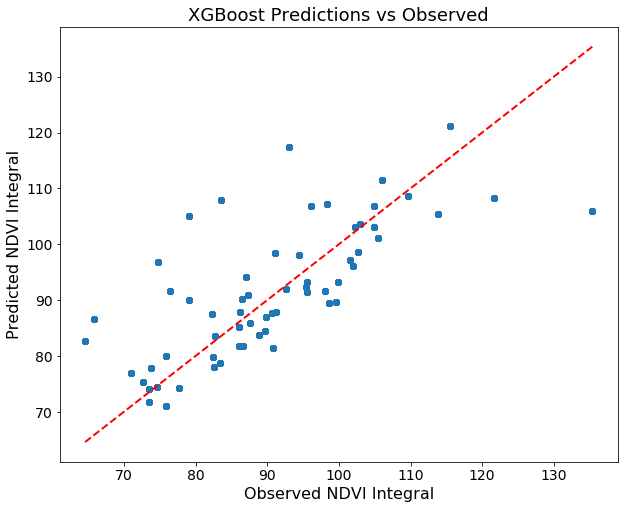

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Observed NDVI Integral', fontsize = 16)
plt.ylabel('Predicted NDVI Integral', fontsize = 16)
plt.title('XGBoost Predictions vs Observed', fontsize = 18)
plt.savefig('img/pred_vs_obs.png')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.show()

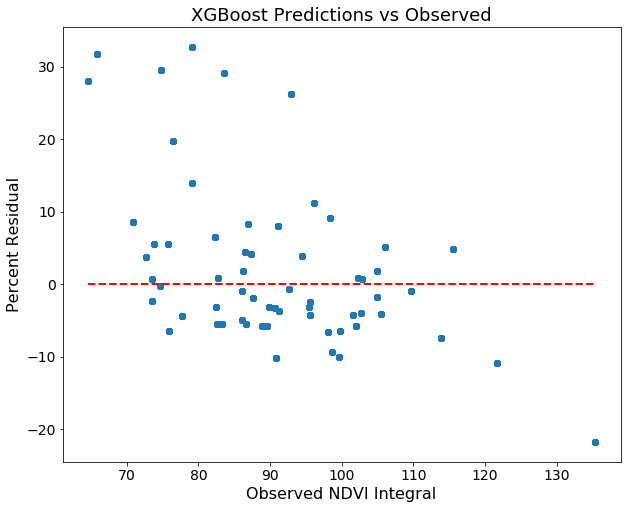

In [11]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, (y_pred - y_test)/y_test * 100, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [0,0], 'r--', linewidth=2)
plt.xlabel('Observed NDVI Integral', fontsize = 16)
plt.ylabel('Percent Residual', fontsize = 16)
plt.title('XGBoost Predictions vs Observed', fontsize = 18)
plt.savefig('img/pred_vs_obs.png')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.show()


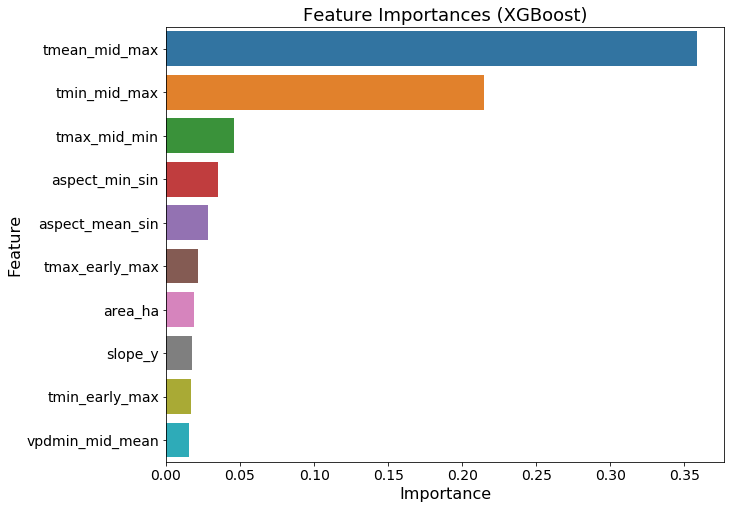

In [12]:
import seaborn as sns

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10))
plt.title('Feature Importances (XGBoost)', fontsize = 18)
plt.xlabel('Importance', fontsize = 16)
plt.ylabel('Feature', fontsize = 16)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('img/feature_imp.png')
plt.show()

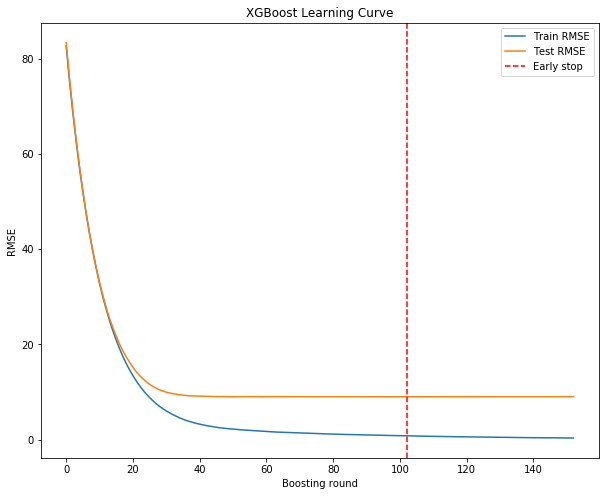

In [13]:
results = xgb_model.evals_result()
plt.figure(figsize = (10,8))
plt.plot(results['validation_0']['rmse'], label='Train RMSE')
plt.plot(results['validation_1']['rmse'], label='Test RMSE')
plt.axvline(xgb_model.best_iteration, color='red', linestyle='--', label='Early stop')
plt.xlabel('Boosting round')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.show()